In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lakshmideepikapeyala/e-commerce-customer-analysis/ecommerce orders.csv
/kaggle/input/datasets/lakshmideepikapeyala/e-commerce-customer-analysis/ecommerce customers.csv


In [3]:
import pandas as pd
import numpy as np

# Load both datasets
customers = pd.read_csv('/kaggle/input/datasets/lakshmideepikapeyala/e-commerce-customer-analysis/ecommerce customers.csv')
orders = pd.read_csv('/kaggle/input/datasets/lakshmideepikapeyala/e-commerce-customer-analysis/ecommerce orders.csv')

print("Customers:", len(customers))
print("Orders (before cleaning):", len(orders))

# Clean orders: remove duplicates
orders = orders.drop_duplicates(subset=['order_id', 'customer_id', 'order_date', 'total_amount'])
print("Orders (after dedup):", len(orders))

# Remove zero-quantity data entry errors
orders = orders[orders['quantity'] > 0]
print("Orders (after removing zero-qty):", len(orders))

# Fill missing payment method
orders['payment_method'] = orders['payment_method'].fillna('Unknown')

# Clean customer city names
customers['city'] = customers['city'].str.strip().str.title()

print("\nMissing values check:")
print(orders.isna().sum())

customers.head()

Customers: 3000
Orders (before cleaning): 9321
Orders (after dedup): 9229
Orders (after removing zero-qty): 9183

Missing values check:
order_id            0
customer_id         0
order_date          0
product_category    0
quantity            0
unit_price          0
total_amount        0
payment_method      0
order_status        0
dtype: int64


,customer_id,signup_date,city,state,age_group,gender,acquisition_channel
0,CUST00498,2026-05-17,Ahmedabad,Gujarat,25-34,Female,Paid Ads
1,CUST02873,2026-01-27,Indore,Madhya Pradesh,35-44,Male,Social Media
2,CUST01530,2024-09-10,Hyderabad,Telangana,25-34,Male,Organic Search
3,CUST01797,2026-02-21,Ahmedabad,Gujarat,18-24,Male,Organic Search
4,CUST00910,2025-04-01,Kolkata,West Bengal,25-34,Female,Email Campaign


In [4]:
import matplotlib.pyplot as plt

# Convert order_date to datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Only use delivered orders for RFM
delivered = orders[orders['order_status'] == 'Delivered']

# Reference date (day after last order in dataset)
reference_date = delivered['order_date'].max() + pd.Timedelta(days=1)

# Calculate RFM per customer
rfm = delivered.groupby('customer_id').agg(
    recency=('order_date', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('total_amount', 'sum')
).reset_index()

# Score each dimension 1-4 (quartiles)
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4]).astype(int)

# Segment customers
def segment(row):
    if row['r_score'] >= 3 and row['f_score'] >= 3 and row['m_score'] >= 3:
        return 'Champions'
    elif row['r_score'] >= 3 and row['f_score'] >= 2:
        return 'Loyal Customers'
    elif row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'At Risk'
    elif row['r_score'] <= 2 and row['f_score'] <= 2:
        return 'Lost/Churned'
    else:
        return 'Potential Loyalist'

rfm['segment'] = rfm.apply(segment, axis=1)

print(rfm['segment'].value_counts())
rfm.head()

segment
Lost/Churned          801
Champions             596
At Risk               473
Loyal Customers       449
Potential Loyalist    240
Name: count, dtype: int64


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,segment
0,CUST00001,99,2,10934.89,2,2,3,Lost/Churned
1,CUST00002,84,5,8380.27,3,4,2,Loyal Customers
2,CUST00003,91,2,33690.85,3,2,4,Loyal Customers
3,CUST00004,312,1,1489.89,1,1,1,Lost/Churned
4,CUST00005,446,1,41610.76,1,1,4,Lost/Churned


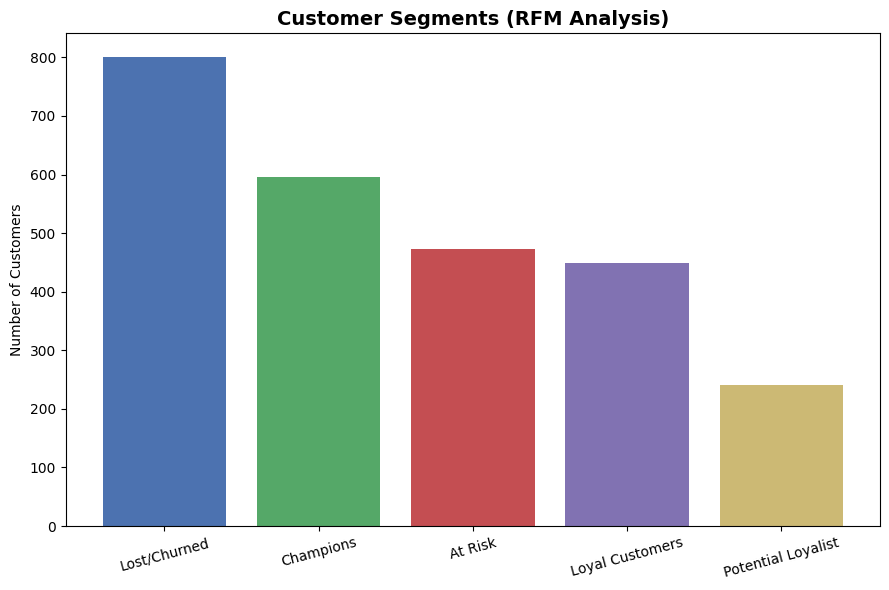

In [5]:
segment_counts = rfm['segment'].value_counts()

plt.figure(figsize=(9, 6))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.ylabel('Number of Customers')
plt.title('Customer Segments (RFM Analysis)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150)
plt.show()

/tmp/ipykernel_58/2592041088.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered['month'] = delivered['order_date'].dt.to_period('M').astype(str)


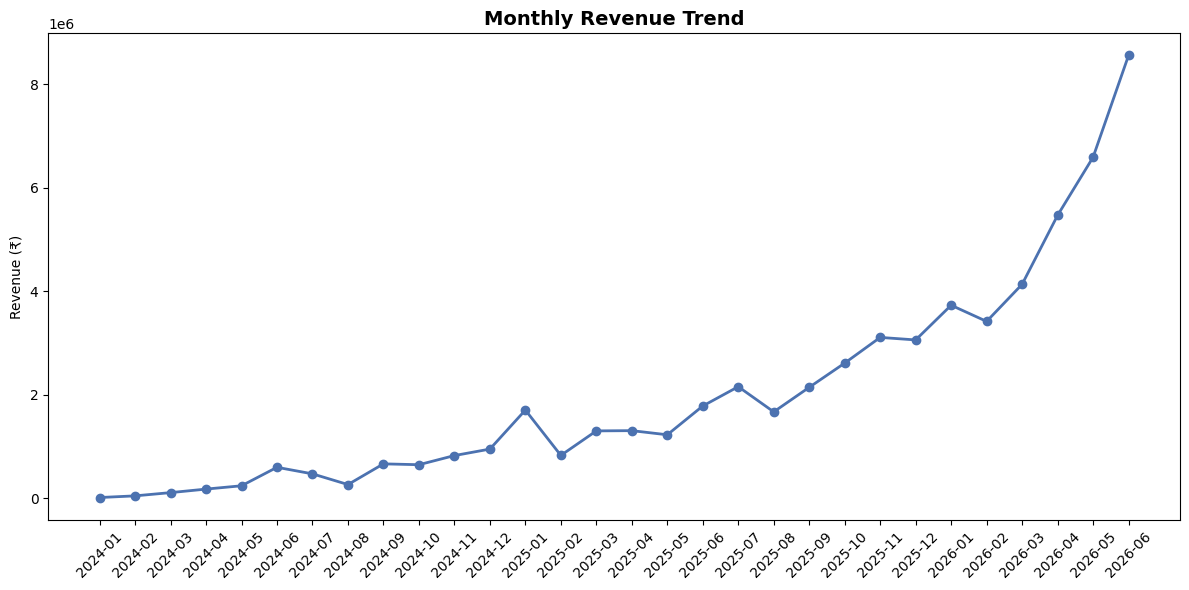

In [7]:
delivered['month'] = delivered['order_date'].dt.to_period('M').astype(str)
monthly_revenue = delivered.groupby('month')['total_amount'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='#4C72B0', linewidth=2)
plt.xticks(rotation=45)
plt.ylabel('Revenue (₹)')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

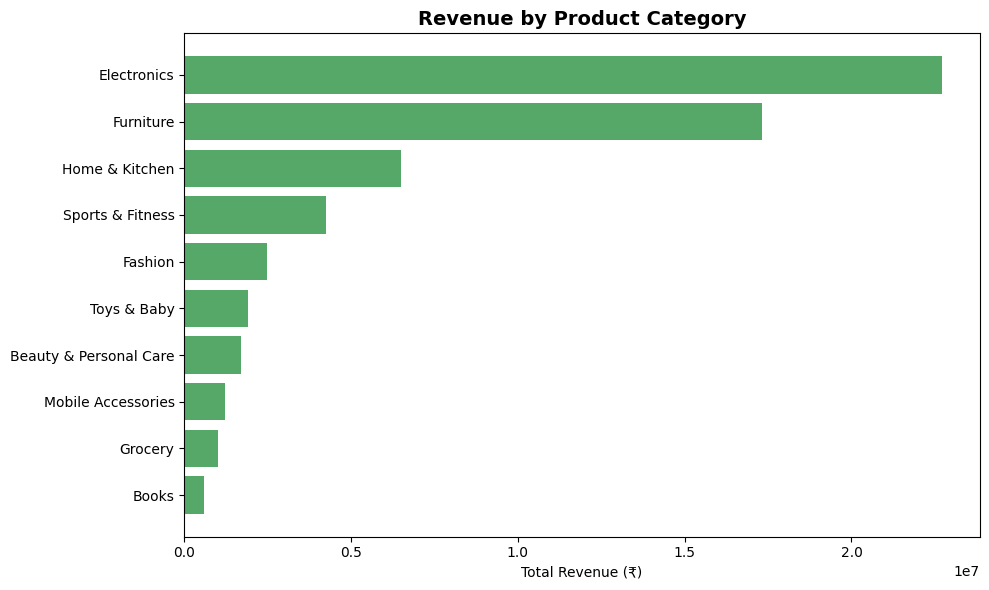

In [8]:
category_revenue = delivered.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(category_revenue.index[::-1], category_revenue.values[::-1], color='#55A868')
plt.xlabel('Total Revenue (₹)')
plt.title('Revenue by Product Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('category_revenue.png', dpi=150)
plt.show()

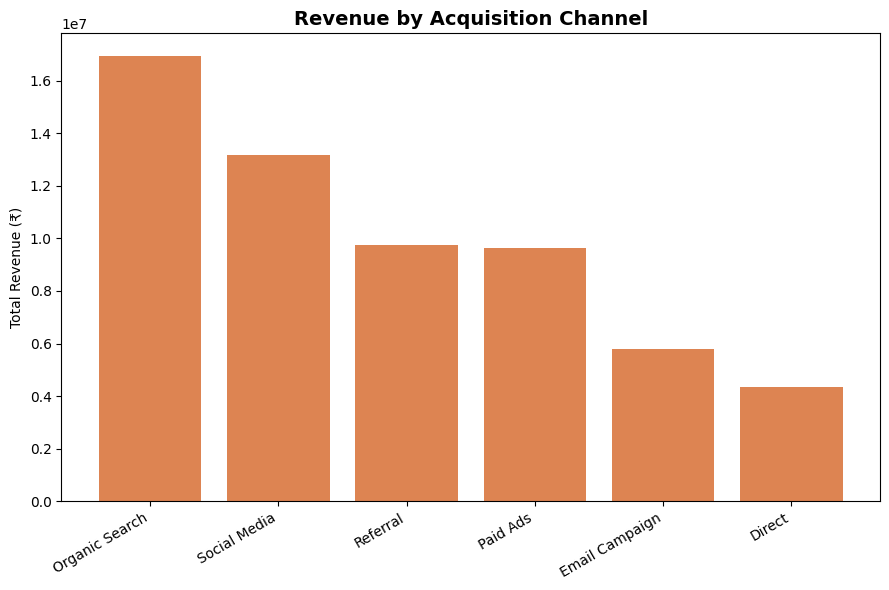

In [9]:
merged = delivered.merge(customers, on='customer_id')
channel_revenue = merged.groupby('acquisition_channel')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
plt.bar(channel_revenue.index, channel_revenue.values, color='#DD8452')
plt.ylabel('Total Revenue (₹)')
plt.title('Revenue by Acquisition Channel', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('channel_revenue.png', dpi=150)
plt.show()

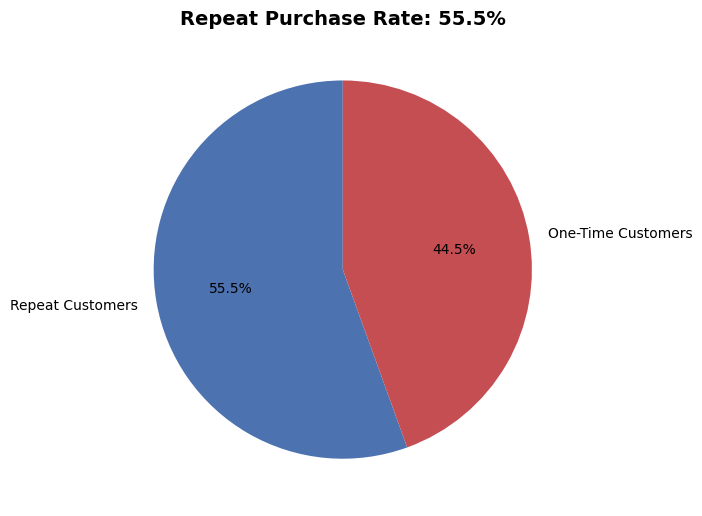

In [10]:
order_counts = delivered.groupby('customer_id')['order_id'].count()
repeat_rate = (order_counts > 1).sum() / len(order_counts) * 100

labels = ['Repeat Customers', 'One-Time Customers']
sizes = [(order_counts > 1).sum(), (order_counts == 1).sum()]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
plt.title(f'Repeat Purchase Rate: {repeat_rate:.1f}%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('repeat_rate.png', dpi=150)
plt.show()